# ***Project Title: Customer Transaction Prediction (PRCP-1003)***

# ***1.Problem Statement***

Banks have a large number of customers, but not all customers perform transactions regularly. Identifying customers who are likely to make transactions in the future is important for improving customer engagement and business growth. This project uses historical customer data to analyze customer behavior and develop a predictive model that can identify which customers are likely to make transactions in the future.

### Objective
1) Prepare a complete data analysis report on the given customer transaction dataset.
2) Create a predictive model that helps the bank identify which customers are likely to make transactions in the future.

### Target:
* 0 = No Transaction
* 1 = Transaction

## ***Domain Analysis***
**Domain:** Banking

# ***2.Import Libraries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# ***3.Load Dataset***

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [4]:
df.shape

(200000, 202)

# ***4.Dataset Overview***

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [6]:
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


# ***5.Missing Values & Duplicates***

In [7]:
df.isnull().sum()

ID_code    0
target     0
var_0      0
var_1      0
var_2      0
          ..
var_195    0
var_196    0
var_197    0
var_198    0
var_199    0
Length: 202, dtype: int64

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(0)

# ***6.Target Variable Analysis***

In [10]:
df["target"].value_counts()

target
0    179902
1     20098
Name: count, dtype: int64

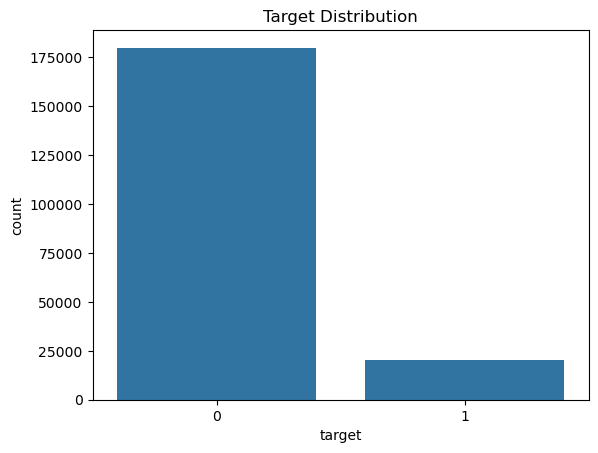

In [11]:
sns.countplot(x='target',data=df)
plt.title("Target Distribution")
plt.show()

# ***7.Percentage Distribution***

In [12]:
target_percent = df["target"].value_counts(normalize=True)*100
print(target_percent)

target
0    89.951
1    10.049
Name: proportion, dtype: float64


# ***8.Remove ID Column***

In [13]:
df.drop("ID_code",axis=1,inplace=True)

# ***9.Feature and Target Separation***

In [14]:
X = df.drop("target",axis=1)
y = df["target"]

# ***10.Train Test Split***

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,
    stratify=y)

# ***11.Feature Scaling***

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ***12.Smote***

In [17]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

# ***13.Model Building***

## A.Logistic Regression

In [18]:
lr = LogisticRegression()
lr.fit(X_train,y_train)
pred_lr = lr.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test,pred_lr))
print("Precision:", precision_score(y_test,pred_lr))
print("Recall:", recall_score(y_test,pred_lr))
print("F1:",f1_score(y_test,pred_lr))
print("ROC AUC:", roc_auc_score(y_test,pred_lr))

Accuracy: 0.78945
Precision: 0.29077946768060836
Recall: 0.7609452736318408
F1: 0.42077028885832185
ROC AUC: 0.7767900353706729


## 2.Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
pred_dt = dt.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test,pred_dt))
print("Precision:", precision_score(y_test,pred_dt))
print("Recall:", recall_score(y_test,pred_dt))
print("F1:",f1_score(y_test,pred_dt))
print("ROC AUC:", roc_auc_score(y_test,pred_dt))

## 3.Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test,pred_rf))
print("Precision:", precision_score(y_test,pred_rf))
print("Recall:", recall_score(y_test,pred_rf))
print("F1:",f1_score(y_test,pred_rf))
print("ROC AUC:", roc_auc_score(y_test,pred_rf))

## 4.Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier()
gb.fit(X_train,y_train)
pred_gb = gb.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test,pred_gb))
print("Precision:", precision_score(y_test,pred_gb))
print("Recall:", recall_score(y_test,pred_gb))
print("F1:",f1_score(y_test,pred_gb))
print("ROC AUC:", roc_auc_score(y_test,pred_gb))

# ***14.Model Comparison Table***

In [ ]:
results = pd.DataFrame({
    'Model':["Logidtic Regression",
             "Decision Tree",
             "Random Forest",
             "Gradient Boosting"],

    "Accuracy":[accuracy_score(y_test,pred_lr),
                accuracy_score(y_test,pred_dt),
                accuracy_score(y_test,pred_rf),
                accuracy_score(y_test,pred_gb)],

    "F1 Score":[f1_score(y_test,pred_lr),
                f1_score(y_test,pred_dt),
                f1_score(y_test,pred_rf),
                f1_score(y_test,pred_gb)],

    "ROC AUC":[roc_auc_score(y_test,pred_lr),
               roc_auc_score(y_test,pred_dt),
               roc_auc_score(y_test,pred_rf),
               roc_auc_score(y_test,pred_gb)]
})

results

# ***15.Confusion Martix***

In [ ]:
cm = confusion_matrix(y_test,pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ***16.Classification Report***

In [ ]:
print(classification_report(y_test, pred_rf))

# ***17.Hyperparameter Tuning***

In [ ]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        'n_estimators':[100,200],
        'max_depth':[5,10]
    },
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train,y_train)

print(grid.best_params_)

# ***18.Final Model***

In [ ]:
best_rf = RandomForestClassifier(
n_estimators=200,
max_depth=10,
random_state=42
)

best_rf.fit(X_train,y_train)

final_pred = best_rf.predict(X_test)

# ***19.Cross Validation***

In [ ]:
cv_scores = cross_val_score(
    best_rf,X_train,y_train,cv=5,scoring="roc_auc")

print(cv_scores)

print("average ROC AUC:",cv_scores.mean())

# ***20.Feature Importance***

In [ ]:
importance = best_rf.feature_importances_

features = X.columns

feature_importance = pd.DataFrame({
    'Feature':features,
    'Importance':importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

# ***21.Business Insights***

1) 90% of customers do not perform transaction.
2) Only a small group of customers actively respond to banking offers.
3) Only 10% of customers are likely to make transactions.
4) These customers are important for increasing bank revenue.
5) The model helps identify customers who are more likely to respond.
6) The model helps to find customers interested in banking products.
7) The dataset is highly imbalanced.
8) The bank can reduce marketing costs by focusing on likely customers.
9) Customer behavior can be predicted using historical data.
10) Machine learning helps improve decision-making.

# ***22.Challenges Faced***

**1. Anonymous Features**

* Challenge: The dataset contains 200 features with names like var_0, var_1, etc., making it difficult to understand their real meaning.

* Solution: Statistical analysis, correlation analysis, and feature importance techniques were used to understand the impact of features.

**2. Imbalanced Dataset**

* Challenge: Around 90% of customers belong to class 0 and only 10% belong to class 1, which can bias the model.

* Solution: Evaluation metrics such as Recall, F1-Score, and ROC-AUC were used, and balancing techniques like SMOTE can be applied.

**3. High Dimensional Data**

* Challenge: The dataset contains 200 features, increasing model complexity and training time.

* Solution: Feature importance analysis was performed to identify the most influential features.

**4. Risk of Overfitting**

* Challenge: Complex models may memorize training data and perform poorly on unseen data.

* Solution: Train-test split, cross-validation, and hyperparameter tuning were used to improve generalization.

**5. Model Selection**

* Challenge: Multiple machine learning algorithms produced different results, making model selection difficult.

* Solution: Models were compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score to select the best-performing model.

**6. Feature Scaling Requirement**

* Challenge: Features had different numerical ranges, which could affect model performance.

* Solution: StandardScaler was applied to normalize feature values before training.

**7. Identifying Minority-Class Customers**

* Challenge: Customers who perform transactions represent only a small portion of the dataset.

* Solution: Focus was placed on Recall and ROC-AUC Score to improve identification of potential transaction customers.


# ***23.Conclusion***

The goal of this project was to predict whether a customer will make a transaction or not. Different machine learning models were built and compared to find the best-performing model.

The dataset was analyzed, cleaned, and prepared before model training. The selected model showed good performance in identifying potential customers.

This model can help banks target the right customers, reduce marketing costs, improve campaign success rates, and increase business profit. Therefore, machine learning can be effectively used to support customer transaction prediction and improve business decision-making.